In [1]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
#===========================================
# Load File 1
#===========================================

with open('Size_Gaussian_0002_MMD.npy', 'rb') as f:
    sample_losses_01_0002 = jnp.load(f)
    
with open('Size_Gaussian_0008_MMD.npy', 'rb') as f:
    sample_losses_01_0008 = jnp.load(f)

with open('Size_Gaussian_0032_MMD.npy', 'rb') as f:
    sample_losses_01_0032 = jnp.load(f)
    
with open('Size_Gaussian_0128_MMD.npy', 'rb') as f:
    sample_losses_01_0128 = jnp.load(f)
    
with open('Size_Gaussian_0512_MMD.npy', 'rb') as f:
    sample_losses_01_0512 = jnp.load(f)
    
with open('Size_Gaussian_2048_MMD.npy', 'rb') as f:
    sample_losses_01_2048 = jnp.load(f)
    
with open('Size_Gaussian_8192_MMD.npy', 'rb') as f:
    sample_losses_01_8192 = jnp.load(f)

with open('Size_Gaussian_32768_MMD.npy', 'rb') as f:
    sample_losses_01_32768 = jnp.load(f)
    

with open('Size_Bimodal_0002_MMD.npy', 'rb') as f:
    sample_losses_02_0002 = jnp.load(f)
    
with open('Size_Bimodal_0008_MMD.npy', 'rb') as f:
    sample_losses_02_0008 = jnp.load(f)

with open('Size_Bimodal_0032_MMD.npy', 'rb') as f:
    sample_losses_02_0032 = jnp.load(f)
    
with open('Size_Bimodal_0128_MMD.npy', 'rb') as f:
    sample_losses_02_0128 = jnp.load(f)
    
with open('Size_Bimodal_0512_MMD.npy', 'rb') as f:
    sample_losses_02_0512 = jnp.load(f)
    
with open('Size_Bimodal_2048_MMD.npy', 'rb') as f:
    sample_losses_02_2048 = jnp.load(f)
    
with open('Size_Bimodal_8192_MMD.npy', 'rb') as f:
    sample_losses_02_8192 = jnp.load(f)

with open('Size_Bimodal_32768_MMD.npy', 'rb') as f:
    sample_losses_02_32768 = jnp.load(f)
    

with open('Size_Banana_0002_MMD.npy', 'rb') as f:
    sample_losses_03_0002 = jnp.load(f)
    
with open('Size_Banana_0008_MMD.npy', 'rb') as f:
    sample_losses_03_0008 = jnp.load(f)

with open('Size_Banana_0032_MMD.npy', 'rb') as f:
    sample_losses_03_0032 = jnp.load(f)
    
with open('Size_Banana_0128_MMD.npy', 'rb') as f:
    sample_losses_03_0128 = jnp.load(f)
    
with open('Size_Banana_0512_MMD.npy', 'rb') as f:
    sample_losses_03_0512 = jnp.load(f)
    
with open('Size_Banana_2048_MMD.npy', 'rb') as f:
    sample_losses_03_2048 = jnp.load(f)
    
with open('Size_Banana_8192_MMD.npy', 'rb') as f:
    sample_losses_03_8192 = jnp.load(f)

with open('Size_Banana_32768_MMD.npy', 'rb') as f:
    sample_losses_03_32768 = jnp.load(f)

sample_losses_01_list = [ sample_losses_01_0002, sample_losses_01_0008, sample_losses_01_0032, sample_losses_01_0128, sample_losses_01_0512, sample_losses_01_2048, sample_losses_01_8192, sample_losses_01_32768 ]
sample_losses_02_list = [ sample_losses_02_0002, sample_losses_02_0008, sample_losses_02_0032, sample_losses_02_0128, sample_losses_02_0512, sample_losses_02_2048, sample_losses_02_8192, sample_losses_02_32768 ]
sample_losses_03_list = [ sample_losses_03_0002, sample_losses_03_0008, sample_losses_03_0032, sample_losses_03_0128, sample_losses_03_0512, sample_losses_03_2048, sample_losses_03_8192, sample_losses_03_32768 ]


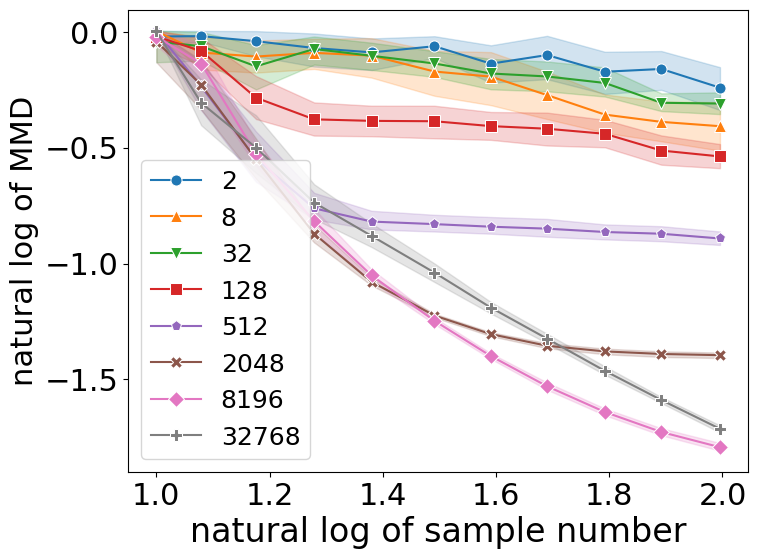

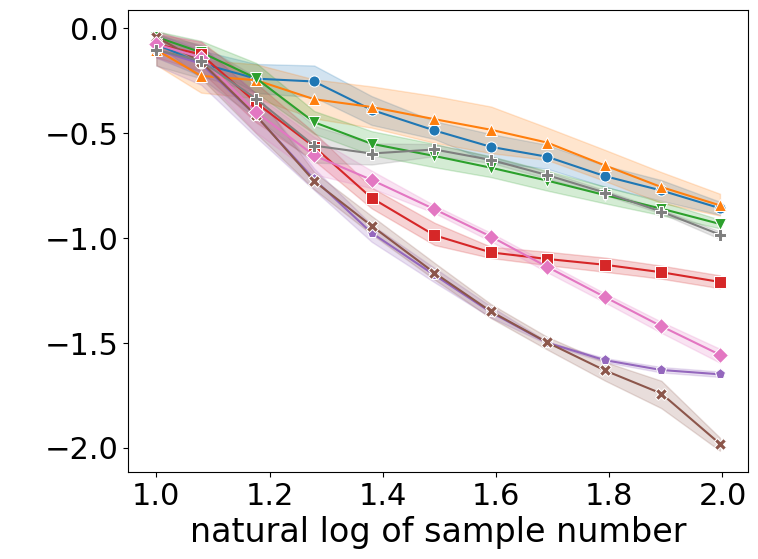

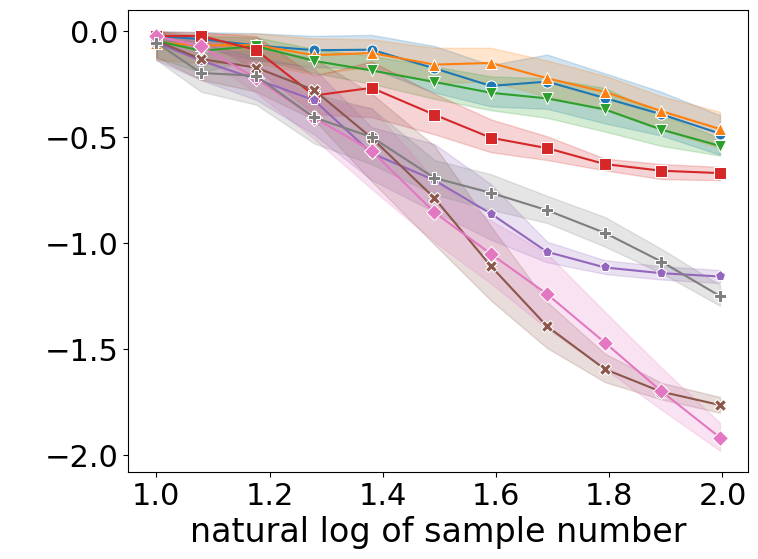

In [20]:
#===========================================
# Visualise Sample Losses
#===========================================

def plot_sample_loss(loss_list, init_num=10, total_num=100, ytick=None, xlabel=True, ylabel=True, legend=True):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    loss_sizes = [ 2, 8, 32, 128, 512, 2048, 8196, 32768 ]
    loss_index = jnp.log10( jnp.array([10, 12, 15, 19, 24, 31, 39, 49, 62, 78, 99]) )
    loss_style = [ 'o', '^', 'v', 's', 'p', 'X', 'D', 'P' ]
    for ith in range(len(loss_list)):
        df = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[ith].flatten())})
        sns.lineplot(df, x='index', y='loss', marker=loss_style[ith], markersize=8, ax=ax, label="{:d}".format(loss_sizes[ith]))
        

    if ytick:
        ax.set_yticks(ytick)
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.set_xlabel("natural log of sample number", fontsize=24) if xlabel else ax.set_xlabel(" ", fontsize=22)
    ax.set_ylabel("natural log of MMD", fontsize=22) if ylabel else ax.set_ylabel(" ", fontsize=22)
    ax.legend(prop=dict(size=18)) if legend else ax.get_legend().remove()

plot_sample_loss(sample_losses_01_list)
plot_sample_loss(sample_losses_02_list, ylabel=False, legend=False)
plot_sample_loss(sample_losses_03_list, ylabel=False, legend=False)
